<a href="https://colab.research.google.com/github/Lijan-Baral/GitHub-CST184/blob/main/Week5_tutorial_Graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Week 5 Tutorial**

Step 1: Load the Data

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load CSVs
nodes_df = pd.read_csv("/content/week5_tutorial_nodes.csv")
edges_df = pd.read_csv("/content/week5_tutorial_edges.csv")

# Create graph
G = nx.Graph()
for _, row in nodes_df.iterrows():
    G.add_node(row['name'], type=row['type'], gender=row['gender'], region=row['region'])

for _, row in edges_df.iterrows():
    G.add_edge(row['Source'], row['Target'], weight=row['Weight'])

📊 Step 2: Analyze Graph Structure

In [4]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is the network connected?", nx.is_connected(G))

# Node degrees
for node in G.nodes():
    print(f"{node}: Degree = {G.degree(node)}")

Number of nodes: 8
Number of edges: 10
Is the network connected? True
Aisha: Degree = 2
Ben: Degree = 3
Chloe: Degree = 3
David: Degree = 2
Elena: Degree = 3
Farid: Degree = 2
Grace: Degree = 3
Hugo: Degree = 2


Prompt: Who is most connected? Who only has 1 connection?

Answer: -Ben, Chloe, Elena, and Grace are the most connected, as they are all tied with the highest degree of 3 connections each.

- No one has only one connection.

Step 3: Explore Centrality and Clustering

In [5]:
# Betweenness Centrality
centrality = nx.betweenness_centrality(G)
print("Betweenness Centrality:")
for k, v in centrality.items():
    print(f"{k}: {round(v, 3)}")

# Clustering Coefficient
clustering = nx.clustering(G)
print("\nClustering Coefficient:")
for k, v in clustering.items():
    print(f"{k}: {round(v, 2)}")

Betweenness Centrality:
Aisha: 0.159
Ben: 0.175
Chloe: 0.198
David: 0.056
Elena: 0.294
Farid: 0.0
Grace: 0.254
Hugo: 0.056

Clustering Coefficient:
Aisha: 0
Ben: 0.33
Chloe: 0
David: 0
Elena: 0
Farid: 1.0
Grace: 0.33
Hugo: 0


Prompt: Who connects different parts of the network? Are there tight-knit groups?

Answer: Elena connects different parts of network with highest 0.294 Betweenness centrality.

Yes due to Farid with maximum possible clustering coefficent.

🎨 Step 4: Visualize with Attributes

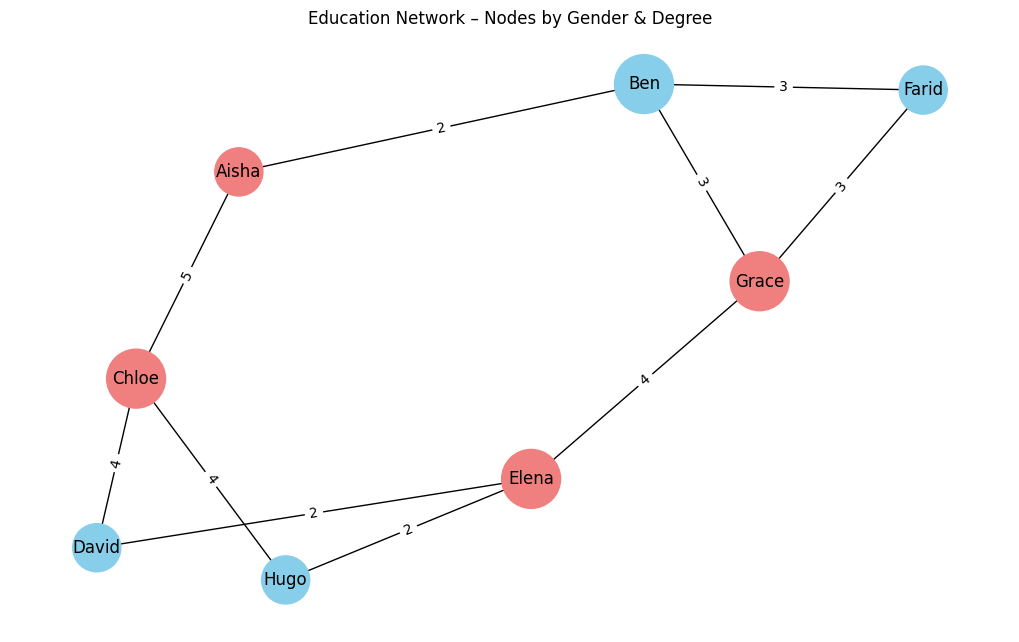

In [6]:
# Layout and attributes
pos = nx.spring_layout(G, seed=42)
gender_colors = {'Male': 'skyblue', 'Female': 'lightcoral'}
node_colors = [gender_colors[G.nodes[n]['gender']] for n in G.nodes]
node_sizes = [G.degree(n) * 600 for n in G.nodes]

plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'))
plt.title("Education Network – Nodes by Gender & Degree")
plt.show()

Prompt: What does this tell you about inclusion and centrality?

Answer: Due to inclusion, tightly-knit groups like Farid, Ben, and Grace enjoy high trust and local integration (high clustering), but they can remain isolated from the broader network. Conversely, high centrality (like Elena's betweenness) grants strategic power to bridge distinct communities, but it does not guarantee local belonging or cohesive group inclusion.

🔁 Step 5: Modify the Network

After removal, is connected? True


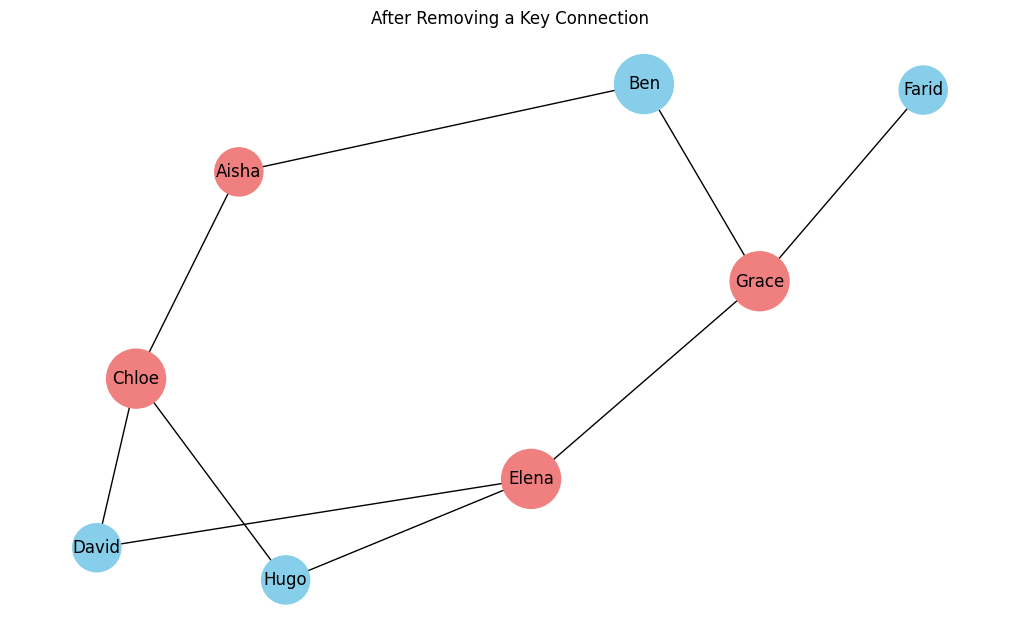

In [7]:
# Try disconnecting a node
G.remove_edge("Ben", "Farid")
print("After removal, is connected?", nx.is_connected(G))

# Re-plot the updated graph
plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=node_sizes)
plt.title("After Removing a Key Connection")
plt.show()

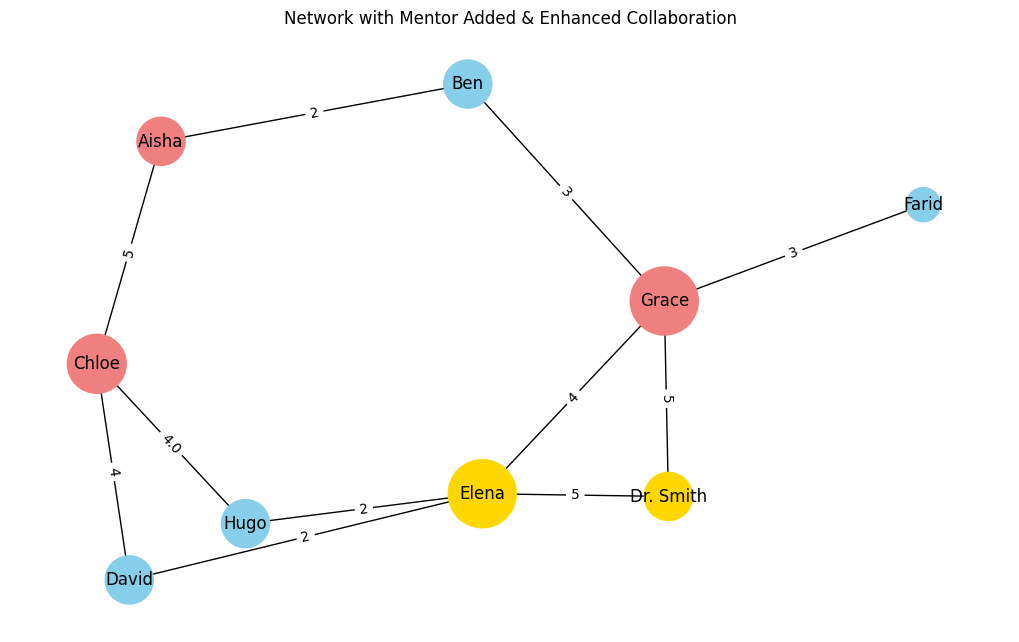

In [10]:
# Try This: Add a new mentor node, or increase weights between students to simulate stronger collaboration.

#  Add a new mentor node and connect them to some students
G.add_node("Dr. Smith", type="Mentor", gender="Male", region="North")
G.add_edge("Dr. Smith", "Elena", weight=5)
G.add_edge("Dr. Smith", "Grace", weight=5)

#  Increase weights between specific students to simulate stronger collaboration
# Let's say Chloe and Hugo start working closely together
G["Chloe"]["Hugo"]['weight'] = 4.0

# Re-plot the updated graph with the new mentor node
plt.figure(figsize=(10, 6))
# Re-calculating colors and sizes to include the new node
node_colors = ['gold' if G.nodes[n].get('type') == 'Mentor' else gender_colors[G.nodes[n]['gender']] for n in G.nodes]
node_sizes = [G.degree(n) * 600 for n in G.nodes]

pos = nx.spring_layout(G, seed=42)  # Recalculate layout for the new node
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'))
plt.title("Network with Mentor Added & Enhanced Collaboration")
plt.show()

📤 Step 6: Save the Graph as a Report Image

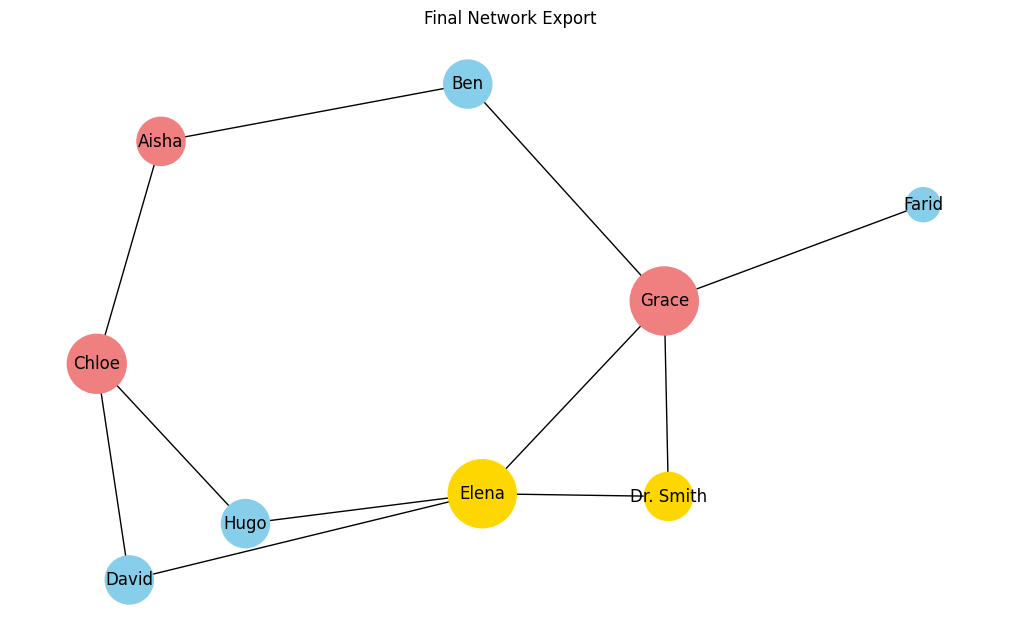

In [11]:
plt.figure(figsize=(10,6))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=node_sizes)
plt.title("Final Network Export")
plt.savefig("week5_network_final.png")
plt.show()